In [1]:
import pandas as pd
import matplotlip.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\lanaa\Downloads\npc_behavior_dataset_100k.csv")
df.head(5)

,episode_id,timestep,npc_health,npc_stamina,player_health,distance_to_player,allies_nearby,enemies_nearby,has_cover,escape_route,player_visible,player_attacking,npc_ammo,npc_weapon,player_weapon,npc_personality,time_since_seen,previous_action,npc_action
0,1,0,69.14,92.93,83.36,6.48,3,3,0,0,1,0,30,SNIPER,SHOTGUN,DEFENSIVE,0,PATROL,ATTACK
1,1,1,69.14,92.93,83.36,6.48,3,3,0,0,1,0,28,SNIPER,SHOTGUN,DEFENSIVE,0,ATTACK,ATTACK
2,1,2,69.14,92.93,83.36,6.48,3,3,0,0,1,1,26,SNIPER,SHOTGUN,DEFENSIVE,0,ATTACK,ATTACK
3,1,3,69.14,92.93,78.84,6.48,3,3,0,0,1,0,25,SNIPER,SHOTGUN,DEFENSIVE,0,ATTACK,CHASE
4,1,4,69.14,90.38,78.84,3.07,3,3,0,0,1,0,25,SNIPER,SHOTGUN,DEFENSIVE,0,CHASE,ATTACK


In [4]:
000, 19)df.shape # 1000 rows and 19 different collumns

(100000, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   episode_id          100000 non-null  int64  
 1   timestep            100000 non-null  int64  
 2   npc_health          100000 non-null  float64
 3   npc_stamina         100000 non-null  float64
 4   player_health       100000 non-null  float64
 5   distance_to_player  100000 non-null  float64
 6   allies_nearby       100000 non-null  int64  
 7   enemies_nearby      100000 non-null  int64  
 8   has_cover           100000 non-null  int64  
 9   escape_route        100000 non-null  int64  
 10  player_visible      100000 non-null  int64  
 11  player_attacking    100000 non-null  int64  
 12  npc_ammo            100000 non-null  int64  
 13  npc_weapon          100000 non-null  str    
 14  player_weapon       100000 non-null  str    
 15  npc_personality     100000 non-null  str    
 

In [6]:
df.describe()

,episode_id,timestep,npc_health,npc_stamina,player_health,distance_to_player,allies_nearby,enemies_nearby,has_cover,escape_route,player_visible,player_attacking,npc_ammo,time_since_seen
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1276.742730,20.874030,63.622563,76.583938,62.004806,18.614140,2.026870,2.553460,0.589240,0.709390,0.522690,0.197860,11.617990,4.184830
std,741.339335,13.986109,18.703570,19.445099,21.277227,12.303966,1.481584,1.209643,0.491974,0.454046,0.499487,0.398388,9.306754,6.936018
min,1.000000,0.000000,1.000000,0.000000,1.000000,1.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,634.000000,9.000000,50.127500,62.520000,48.130000,9.740000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,1270.000000,19.000000,63.830000,78.650000,63.050000,15.700000,2.000000,3.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000
75%,1922.000000,31.000000,78.260000,94.702500,78.390000,25.970000,3.000000,4.000000,1.000000,1.000000,1.000000,0.000000,19.000000,6.000000
max,2560.000000,59.000000,99.960000,100.000000,99.990000,50.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,30.000000,67.000000


In [8]:
# this is tells us how many different behaviors the NPC has
df['npc_action'].value_counts()

npc_action
TAKE_COVER    27366
SEARCH        23190
CHASE         17141
RETREAT       15243
ATTACK        14418
PATROL         2642
Name: count, dtype: int64

In [9]:
df['npc_action'].value_counts(normalize=True) * 100

npc_action
TAKE_COVER    27.366
SEARCH        23.190
CHASE         17.141
RETREAT       15.243
ATTACK        14.418
PATROL         2.642
Name: proportion, dtype: float64

<Axes: xlabel='npc_action'>

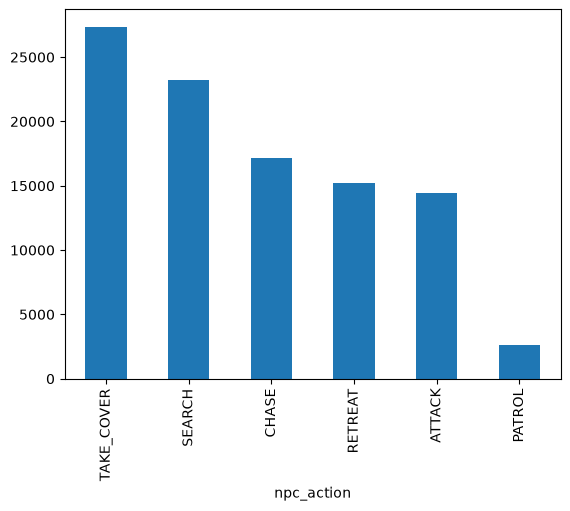

In [12]:
df["npc_action"].value_counts().plot(kind="bar")

In [16]:
##understanding the episodes and how long are they and whether they are consistent or not
##so after that we fix leaking problem

df['episode_id'].nunique()

2560

In [14]:
df.groupby('episode_id')['timestep'].max().describe()

count    2560.000000
mean       38.062500
std        12.000977
min         7.000000
25%        28.000000
50%        38.000000
75%        48.000000
max        59.000000
Name: timestep, dtype: float64

In [15]:
df.groupby('episode_id').size().describe()

count    2560.000000
mean       39.062500
std        12.000977
min         8.000000
25%        29.000000
50%        39.000000
75%        49.000000
max        60.000000
dtype: float64

In [17]:
episode_lengths = df.groupby("episode_id").size()

In [18]:
episode_lengths.describe()

count    2560.000000
mean       39.062500
std        12.000977
min         8.000000
25%        29.000000
50%        39.000000
75%        49.000000
max        60.000000
dtype: float64

In [20]:
episode_lengths.head(10)

episode_id
1     23
2     23
3     52
4     43
5     37
6     54
7     43
8     48
9     22
10    52
dtype: int64

In [22]:
# checking if there is any duplicates to see if episode, timestep appears more than once
df.duplicated(subset=['episode_id', 'timestep']).sum()

np.int64(0)

In [28]:
for col in ['npc_weapon', 'player_weapon', 'npc_personality','previous_action', 'npc_action']:
    print(f'\n  "{col}"  ')
    print(df[col].value_counts())


  "npc_weapon"  
npc_weapon
RIFLE      21209
SNIPER     20296
SMG        20205
PISTOL     19350
SHOTGUN    18940
Name: count, dtype: int64

  "player_weapon"  
player_weapon
SNIPER     21451
SHOTGUN    20152
SMG        19559
PISTOL     19530
RIFLE      19308
Name: count, dtype: int64

  "npc_personality"  
npc_personality
DEFENSIVE     25618
COWARDLY      25537
TACTICAL      25354
AGGRESSIVE    23491
Name: count, dtype: int64

  "previous_action"  
previous_action
TAKE_COVER    26620
SEARCH        22599
CHASE         16773
RETREAT       14736
ATTACK        14135
PATROL         5137
Name: count, dtype: int64

  "npc_action"  
npc_action
TAKE_COVER    27366
SEARCH        23190
CHASE         17141
RETREAT       15243
ATTACK        14418
PATROL         2642
Name: count, dtype: int64


In [29]:
# now to check our ranges 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
episode_id,100000.0,1276.742730,741.339335,1.0,634.0000,1270.00,1922.0000,2560.00
timestep,100000.0,20.874030,13.986109,0.0,9.0000,19.00,31.0000,59.00
npc_health,100000.0,63.622563,18.703570,1.0,50.1275,63.83,78.2600,99.96
npc_stamina,100000.0,76.583938,19.445099,0.0,62.5200,78.65,94.7025,100.00
player_health,100000.0,62.004806,21.277227,1.0,48.1300,63.05,78.3900,99.99
distance_to_player,100000.0,18.614140,12.303966,1.5,9.7400,15.70,25.9700,50.00
allies_nearby,100000.0,2.026870,1.481584,0.0,1.0000,2.00,3.0000,5.00
enemies_nearby,100000.0,2.553460,1.209643,1.0,1.0000,3.00,4.0000,5.00
has_cover,100000.0,0.589240,0.491974,0.0,0.0000,1.00,1.0000,1.00
escape_route,100000.0,0.709390,0.454046,0.0,0.0000,1.00,1.0000,1.00
